In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# load model

In [2]:
from b_models.hsami.recnet import RecNet
from b_models.hsami.hsami_alternate import HSAMI
from b_models.hsami.denoiser import Denoiser
from b_models.configs.hsami_config import HSAMI_Training_Config

config = HSAMI_Training_Config()

recnet = RecNet(config).to(device)

denoiser_x = Denoiser(
    config.input_dim, 
    hidden_dim=config.hidden_dim_x, 
    num_blocks=config.num_blocks_x, 
    time_dim=config.time_dim_x, 
    activation=config.activation
).to(device)

denoiser_y = Denoiser(
    config.latent_dim_y, 
    hidden_dim=config.hidden_dim_y, 
    num_blocks=config.num_blocks_y, 
    time_dim=config.time_dim_y, 
    activation=config.activation
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

In [3]:
# test input
x = torch.randn(5, config.input_dim).to(device)

hsami_output = hsami(x)
target_x, prediction_x, target_y, prediction_y, weight, rate_y, rate_z, debug_norms = hsami_output
print("target_x shape:", target_x.shape)
print("prediction_x shape:", prediction_x.shape)
print("target_y shape:", target_y.shape)
print("prediction_y shape:", prediction_y.shape)
print("weight shape:", weight.shape)
print("rate_y shape:", rate_y.shape)
print("rate_z shape:", rate_z.shape)

target_x shape: torch.Size([5, 2])
prediction_x shape: torch.Size([5, 2])
target_y shape: torch.Size([5, 2])
prediction_y shape: torch.Size([5, 2])
weight shape: torch.Size([5, 1])
rate_y shape: torch.Size([5])
rate_z shape: torch.Size([5])


In [4]:
target_x

tensor([[ 0.0285, -1.8590],
        [-0.2837,  0.2386],
        [-1.7427, -0.2424],
        [-0.9455, -0.6121],
        [ 1.3147, -0.5488]], device='cuda:0')

In [5]:
prediction_x

tensor([[-1.3867e+00,  1.7001e-01],
        [-3.0618e+02,  1.5389e+02],
        [-2.9501e+01, -1.0978e+02],
        [ 2.7088e-01,  1.8619e-01],
        [ 1.9856e-01,  8.2602e-01]], device='cuda:0', grad_fn=<SubBackward0>)

# dataset

In [6]:
from a_datasets.gsm.data import HierarchicalGSM, GSMDataset, load_gsm_dataset

x, (z, y) = load_gsm_dataset(
    num_samples = config.dataset_size,
    sigma_z = config.sigma_z,
    lambdas = config.lambdas,
    A = config.A,
    sigma_x = config.sigma_x,
    seed = config.seed,
)

print("x shape:", x.shape)
print("z shape:", z.shape)
print("y shape:", y.shape)

x shape: torch.Size([100000, 2])
z shape: (100000,)
y shape: (100000, 2)


# train network

In [2]:
from b_models.hsami.training_script import train
train()

device: cuda
parameters: 353,924
run dir: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints/20260617_223233
t_y curriculum: hard_max=186 (sqrt_ab=0.1), full range in 120000 steps
loaded denoiser_x checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints/denoiser_x_pretrain.pt
epoch     0 | step       0 | loss 143622944.0000 | mse_x 143622768.0000 | mse_y 177.4037 | rate_y 5.9340 | rate_z 0.6509 | beta 1.00e-10 | t_y_max 186/199 | enc_lr 1.00e-05 | den_x_lr 0.00e+00 | den_y_lr 0.00e+00
  norms: pred_noise_y 1.176e-01 | a_min 1.021e-01 | score_x|ye 3.629e+00 | score_xz|ye 3.731e+00 | score_z|ye 2.651e-01 | score_y|xg 2.104e+03 | pred_y_unguided 1.641e+00 | pred_y_guided_by_xz 2.062e+01 | noise_x_guided 1.268e+03
epoch    20 | step     500 | loss 3842824.7500 | mse_x 3842635.5000 | mse_y 189.3461 | rate_y 5.2170 | rate_z 0.5417 | beta 2.57e-09 | t_y_max 186/199 | enc_lr 1.00e-05 | den_x_lr 2.00e-07 | den_y_lr 2.00e-07
  norms: pred_noise_y 1.178e-01 | 

# conditional generation

In [8]:
# load the trained model
# model_path = notebook_dir + "/c_training/hsami_checkpoints/20260617_223233/epoch_005000.pt"
model_path = "/mnt/home/blyo1/hdiva/c_training/hsami_checkpoints/sequential_20260618_033947/stage4_epoch_003000.pt"
hsami.load_state_dict(torch.load(model_path)["model_state_dict"])
hsami.to(device).eval();


In [9]:
# get a sample from the dataset
example_datum = x[0].to(device)
example_datum.shape

torch.Size([2])

In [10]:
x_sample = hsami.conditional_generation(5, example_datum.unsqueeze(0))

In [11]:
x_sample

tensor([[ 0.7672, -0.6027],
        [-0.3716, -0.4007],
        [ 0.2964,  0.4529],
        [ 0.2432,  0.2057],
        [-0.5481, -0.3066]], device='cuda:0', requires_grad=True)

In [12]:
example_datum

tensor([ 1.0902, -0.2710], device='cuda:0')

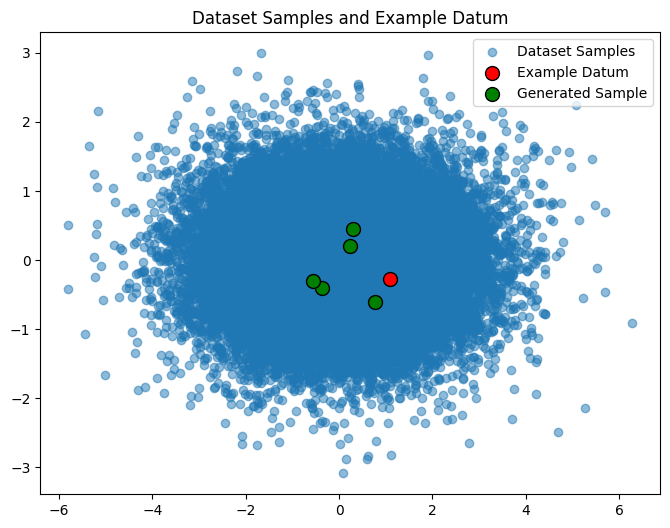

In [13]:
# plot the example datum among the dataset
x_cpu = x.cpu().numpy()
example_datum_cpu = example_datum.cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(x_cpu[:, 0], x_cpu[:, 1], alpha=0.5, label='Dataset Samples')
plt.scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)
# now plot the generated sample as well
x_sample_cpu = x_sample.detach().cpu().numpy()
plt.scatter(x_sample_cpu[:, 0], x_sample_cpu[:, 1], color='green', label='Generated Sample', edgecolor='black', s=100)
plt.title('Dataset Samples and Example Datum')
# plt.xlabel('x[0]')
# plt.ylabel('x[1]')
plt.legend()

# train sequentially

In [3]:
from b_models.hsami.sequential_training import train
train()

device: cuda
parameters: 416,396
run dir: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints/sequential_20260621_020933
=== Stage 1: denoiser_x unconditional (200 epochs) ===
[stage1] epoch     0 | step       0 | loss 1.0401 | lr 0.00e+00
[stage1] epoch    20 | step     100 | loss 0.9752 | lr 8.00e-05
[stage1] epoch    40 | step     200 | loss 0.4384 | lr 1.60e-04
[stage1] epoch    60 | step     300 | loss 0.4462 | lr 1.98e-04
[stage1] epoch    80 | step     400 | loss 0.4462 | lr 1.83e-04
saved checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints/sequential_20260621_020933/stage1_epoch_000100.pt
[stage1] epoch   100 | step     500 | loss 0.4321 | lr 1.55e-04
[stage1] epoch   120 | step     600 | loss 0.4141 | lr 1.19e-04
[stage1] epoch   140 | step     700 | loss 0.4218 | lr 8.22e-05
[stage1] epoch   160 | step     800 | loss 0.4420 | lr 4.98e-05
[stage1] epoch   180 | step     900 | loss 0.4515 | lr 2.78e-05
saved checkpoint: /mnt/ceph/users/bl

# see if stage 1 and stage 2 are working

## stage 1: x denoiser

In [ ]:
# load denoiser x only
from b_models.configs.hsami_config import HSAMI_Training_Config

checkpoint_dir = "/mnt/home/blyo1/hdiva/c_training/hsami_checkpoints/sequential_20260618_033947"

config = HSAMI_Training_Config()
config_path = checkpoint_dir + "/config.json"
config.load_from_json(config_path)

checkpoint_path = checkpoint_dir + "/stage1_epoch_000500.pt"
checkpoint = torch.load(checkpoint_path)
hsami_state_dict = checkpoint["model_state_dict"]
hsami.load_state_dict(hsami_state_dict)
hsami.to(device).eval();

In [ ]:
samples = hsami.unconditional_sample(2000, denoiser_type="x")

In [45]:
samples.shape

torch.Size([2000, 2])

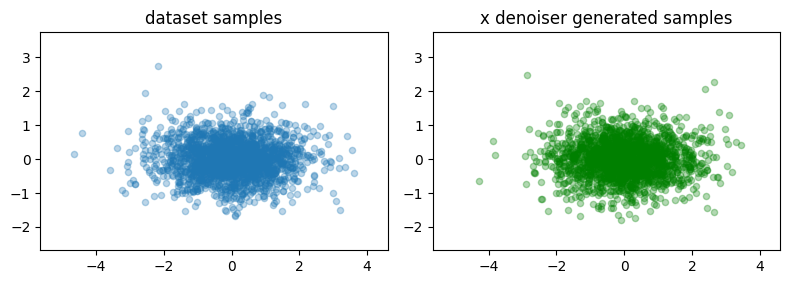

In [55]:
# plot the example datum among the dataset
x_cpu = x.cpu().numpy()[:2000]
example_datum_cpu = example_datum.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].scatter(x_cpu[:, 0], x_cpu[:, 1], alpha=0.3, s=20, label='Dataset Samples')
ax[0].set_title('dataset samples')
# now plot the generated sample as well
samples_cpu = samples.detach().cpu().numpy()
ax[1].scatter(samples_cpu[:, 0], samples_cpu[:, 1], color='green', label='Generated Sample', alpha=0.3, s=20)
ax[1].set_title('x denoiser generated samples')
# match axes
ax[0].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[0].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
ax[1].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[1].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
# set equal aspect ratio
plt.tight_layout()
ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

## stage 2: x denoiser and x->y encoder

In [57]:
# load x denoiser and x->y recnet
from b_models.configs.hsami_config import HSAMI_Training_Config

checkpoint_dir = "/mnt/home/blyo1/hdiva/c_training/hsami_checkpoints/sequential_20260618_033947"

config = HSAMI_Training_Config()
config_path = checkpoint_dir + "/config.json"
config.load_from_json(config_path)

checkpoint_path = checkpoint_dir + "/stage2_epoch_001000.pt"
checkpoint = torch.load(checkpoint_path)
hsami_state_dict = checkpoint["model_state_dict"]
hsami.load_state_dict(hsami_state_dict)
hsami.to(device).eval();

In [ ]:
# get a sample from the dataset
example_datum = x[0].to(device)

stage2_samples = hsami.stage2_generation(1000, example_datum.unsqueeze(0))
stage2_samples.shape

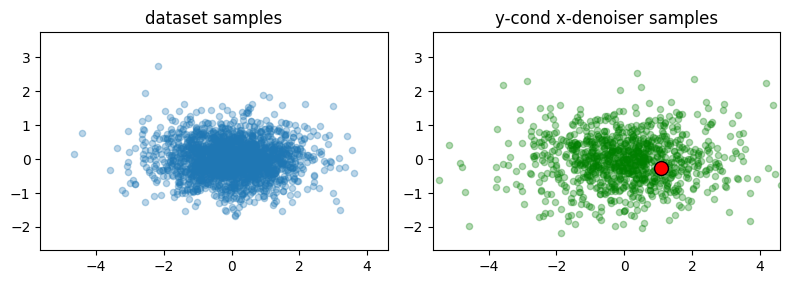

In [65]:
# plot the example datum among the dataset
x_cpu = x.cpu().numpy()[:2000]
example_datum_cpu = example_datum.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].scatter(x_cpu[:, 0], x_cpu[:, 1], alpha=0.3, s=20, label='Dataset Samples')
ax[0].set_title('dataset samples')
# now plot the generated sample as well
stage2_samples_cpu = stage2_samples.detach().cpu().numpy()
ax[1].scatter(stage2_samples_cpu[:, 0], stage2_samples_cpu[:, 1], color='green', label='Generated Sample', alpha=0.3, s=20)
ax[1].set_title('y-cond x-denoiser samples')

ax[1].scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)

# match axes
ax[0].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[0].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
ax[1].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[1].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
# set equal aspect ratio
plt.tight_layout()
ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')